# Phase 3 — Exploratory Data Analysis
Intelligent E-Commerce Customer Analytics Platform (Olist dataset)

Explores sales trends, category performance, delivery performance, review
distribution, payment behavior, and geographic patterns using the cleaned
datasets from Phase 1–2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

OUT = "../outputs/"

orders = pd.read_csv(OUT + "orders_master_clean.csv", parse_dates=[
    "order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"
])
items = pd.read_csv(OUT + "items_enriched.csv")
cust = pd.read_csv(OUT + "customer_master_clean.csv", parse_dates=["first_purchase", "last_purchase"])

delivered = orders[orders["order_status"] == "delivered"]
print("orders:", orders.shape, " items:", items.shape, " customers:", cust.shape)

orders: (99441, 32)  items: (112650, 19)  customers: (96096, 23)


## 1. Sales trend over time

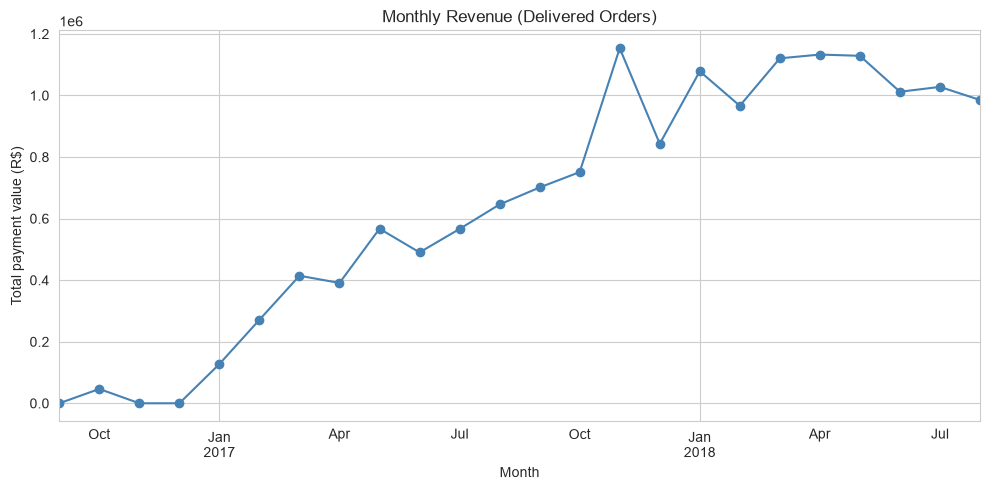

In [2]:
monthly = (delivered.set_index("order_purchase_timestamp")
           .resample("MS")["total_payment_value"].sum())

fig, ax = plt.subplots()
monthly.plot(ax=ax, marker="o", color="steelblue")
ax.set_title("Monthly Revenue (Delivered Orders)")
ax.set_ylabel("Total payment value (R$)")
ax.set_xlabel("Month")
plt.tight_layout()
plt.savefig(OUT + "eda_monthly_revenue.png", dpi=110)
plt.show()

## 2. Order volume by weekday and hour

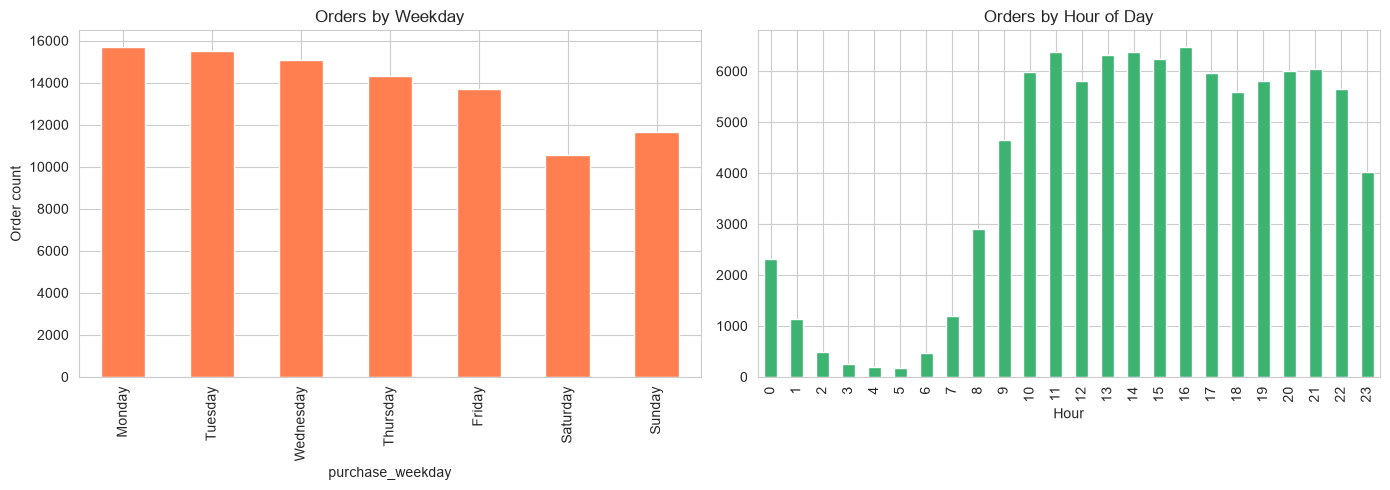

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
delivered["purchase_weekday"].value_counts().reindex(weekday_order).plot(
    kind="bar", ax=axes[0], color="coral")
axes[0].set_title("Orders by Weekday")
axes[0].set_ylabel("Order count")

delivered["purchase_hour"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="mediumseagreen")
axes[1].set_title("Orders by Hour of Day")
axes[1].set_xlabel("Hour")
plt.tight_layout()
plt.savefig(OUT + "eda_weekday_hour.png", dpi=110)
plt.show()

## 3. Top product categories by revenue and order count

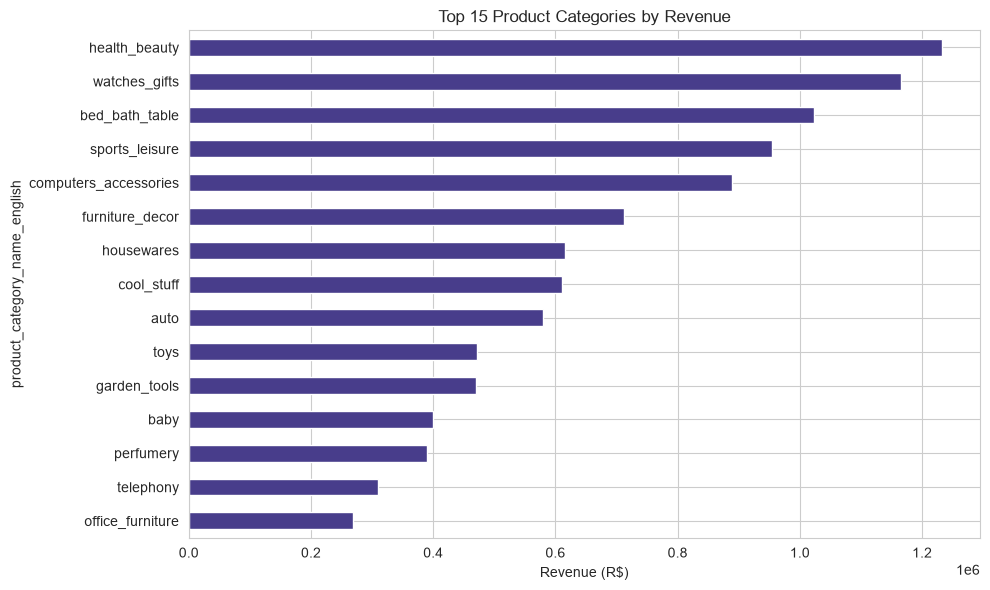

                                  revenue  n_orders
product_category_name_english                      
health_beauty                  1233131.72      8647
watches_gifts                  1166176.98      5495
bed_bath_table                 1023434.76      9272
sports_leisure                  954852.55      7530
computers_accessories           888724.61      6530
furniture_decor                 711927.69      6307
housewares                      615628.69      5743
cool_stuff                      610204.10      3559
auto                            578966.65      3810
toys                            471286.48      3804
garden_tools                    470495.28      3448
baby                            400421.84      2809
perfumery                       390144.65      3086
telephony                       309860.23      4093
office_furniture                268154.31      1254


In [4]:
item_rev = (items.merge(orders[["order_id", "order_status"]], on="order_id")
            .query("order_status == 'delivered'")
            .groupby("product_category_name_english")
            .agg(revenue=("price", "sum"), n_orders=("order_id", "nunique"))
            .sort_values("revenue", ascending=False)
            .head(15))

fig, ax = plt.subplots(figsize=(10, 6))
item_rev["revenue"].sort_values().plot(kind="barh", ax=ax, color="darkslateblue")
ax.set_title("Top 15 Product Categories by Revenue")
ax.set_xlabel("Revenue (R$)")
plt.tight_layout()
plt.savefig(OUT + "eda_top_categories.png", dpi=110)
plt.show()

print(item_rev)

## 4. Delivery performance

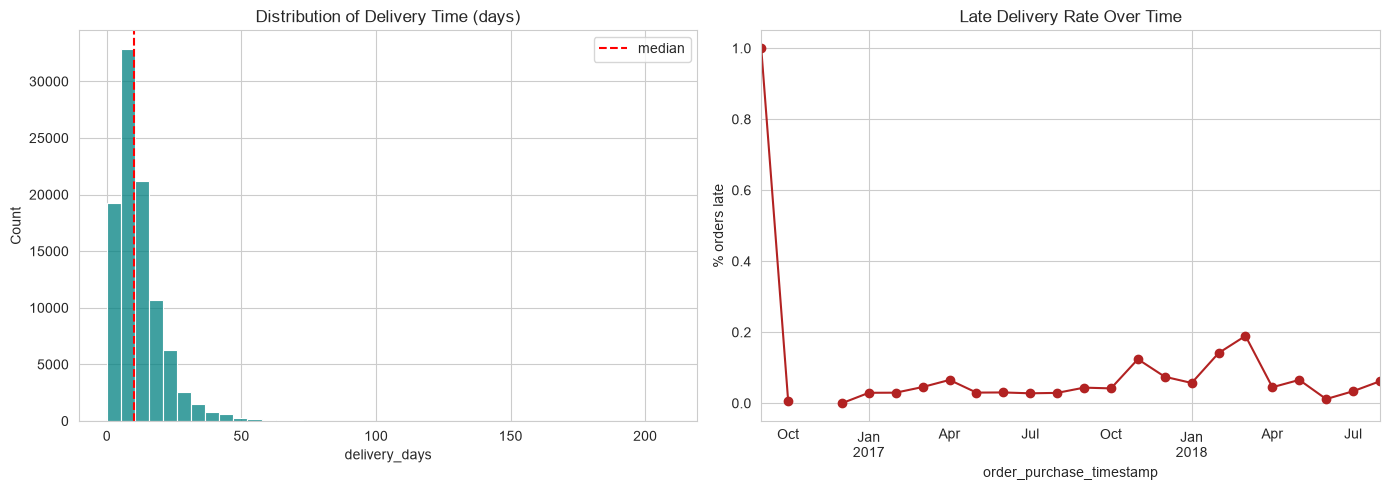

Overall late delivery rate: 6.8%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(delivered["delivery_days"].dropna(), bins=40, ax=axes[0], color="teal")
axes[0].set_title("Distribution of Delivery Time (days)")
axes[0].axvline(delivered["delivery_days"].median(), color="red", linestyle="--", label="median")
axes[0].legend()

late_rate_by_month = delivered.set_index("order_purchase_timestamp").resample("MS")["is_late"].mean()
late_rate_by_month.plot(ax=axes[1], marker="o", color="firebrick")
axes[1].set_title("Late Delivery Rate Over Time")
axes[1].set_ylabel("% orders late")
plt.tight_layout()
plt.savefig(OUT + "eda_delivery_performance.png", dpi=110)
plt.show()

print("Overall late delivery rate: {:.1%}".format(delivered["is_late"].mean()))

## 5. Review score distribution & relationship to delivery delay

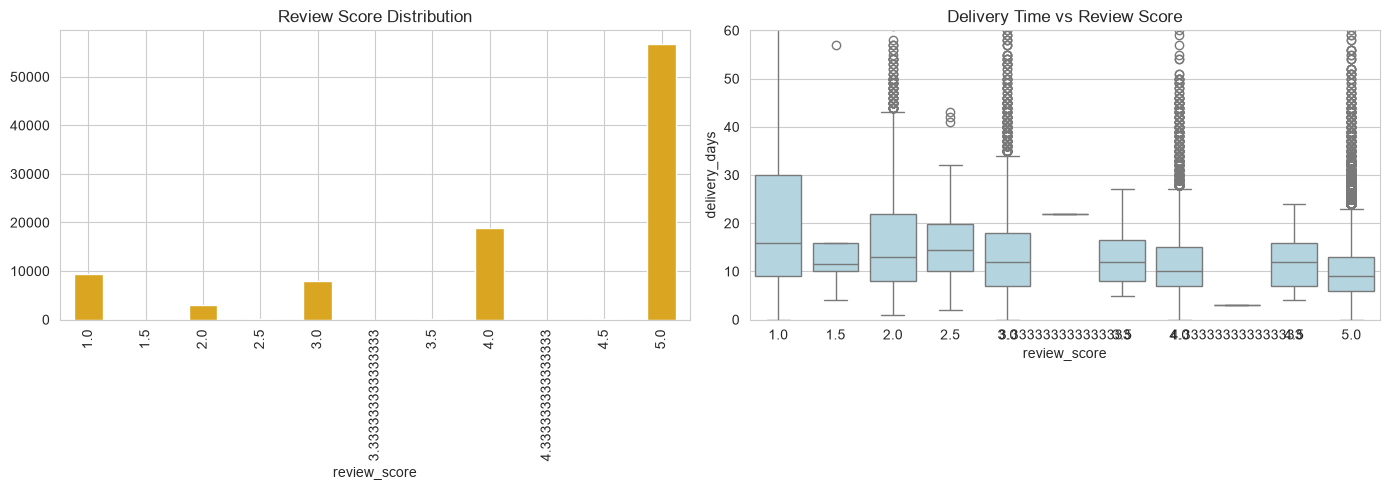

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
delivered["review_score"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="goldenrod")
axes[0].set_title("Review Score Distribution")

sns.boxplot(data=delivered, x="review_score", y="delivery_days", ax=axes[1], color="lightblue")
axes[1].set_title("Delivery Time vs Review Score")
axes[1].set_ylim(0, 60)
plt.tight_layout()
plt.savefig(OUT + "eda_reviews.png", dpi=110)
plt.show()

## 6. Payment method preferences

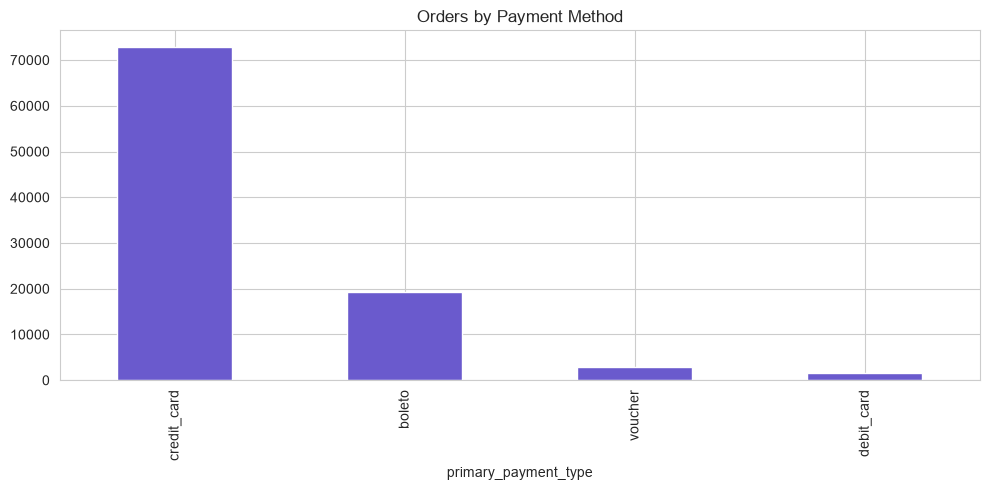

In [7]:
fig, ax = plt.subplots()
delivered["primary_payment_type"].value_counts().plot(kind="bar", ax=ax, color="slateblue")
ax.set_title("Orders by Payment Method")
plt.tight_layout()
plt.savefig(OUT + "eda_payment_methods.png", dpi=110)
plt.show()

## 7. Geographic distribution of customers (by state)

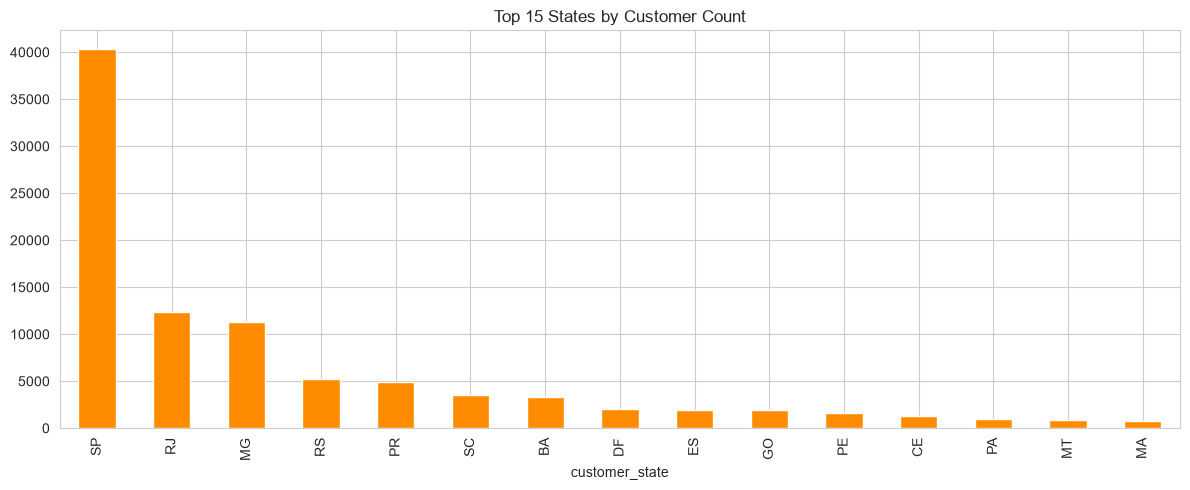

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
cust["customer_state"].value_counts().head(15).plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Top 15 States by Customer Count")
plt.tight_layout()
plt.savefig(OUT + "eda_customer_states.png", dpi=110)
plt.show()

## 8. Customer-level RFM distributions

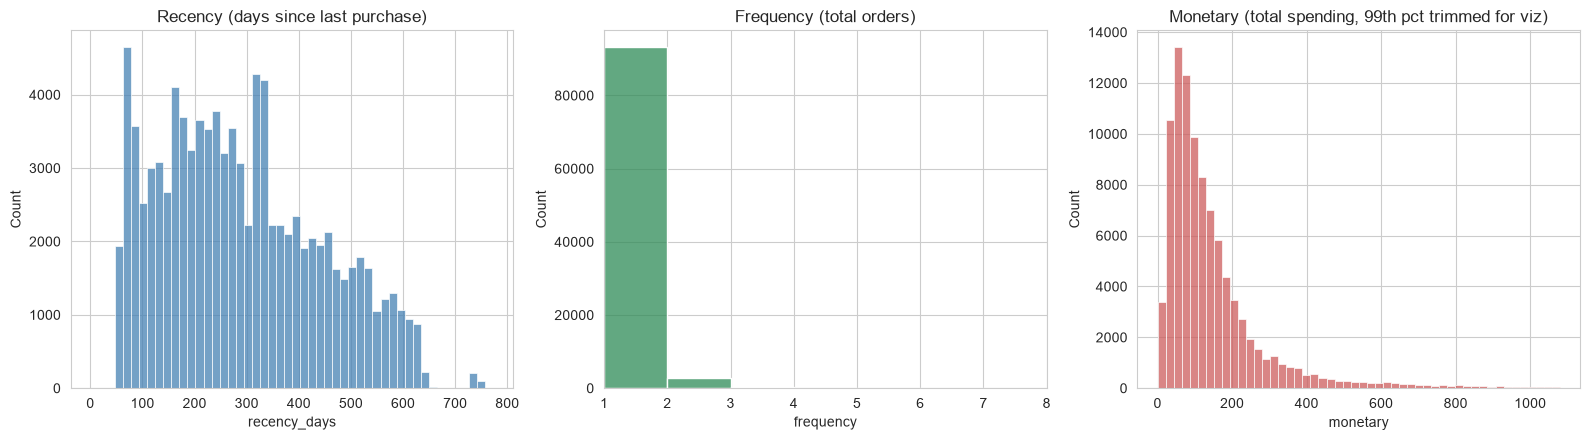

       recency_days     frequency      monetary
count  96096.000000  96096.000000  96096.000000
mean     288.735691      1.034809    160.490153
std      153.414676      0.214384    224.753434
min        1.000000      1.000000      0.000000
25%      164.000000      1.000000     59.460000
50%      269.000000      1.000000    104.930000
75%      398.000000      1.000000    178.510000
max      773.000000     17.000000  13664.080000


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(cust["recency_days"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Recency (days since last purchase)")

sns.histplot(cust["frequency"], bins=range(1, 10), ax=axes[1], color="seagreen")
axes[1].set_title("Frequency (total orders)")
axes[1].set_xlim(1, 8)

sns.histplot(cust[cust["monetary"] < cust["monetary"].quantile(0.99)]["monetary"],
             bins=50, ax=axes[2], color="indianred")
axes[2].set_title("Monetary (total spending, 99th pct trimmed for viz)")
plt.tight_layout()
plt.savefig(OUT + "eda_rfm_distributions.png", dpi=110)
plt.show()

print(cust[["recency_days", "frequency", "monetary"]].describe())

## Key EDA takeaways
- Revenue shows clear month-over-month growth with seasonal spikes (e.g. Nov/Black Friday).
- Order activity peaks midweek during business hours (10am–4pm), tapering on weekends.
- `cama_mesa_banho`, `beleza_saude`, and `esporte_lazer` are consistently top revenue categories.
- Median delivery time and late-delivery rate both show a downward trend over time — logistics improved.
- Review scores drop sharply as delivery delay increases — delivery speed is a strong driver of satisfaction.
- Credit card dominates as a payment method, followed by boleto.
- Customer base is heavily concentrated in SP, RJ, MG — expected given Brazil's population/economic distribution.
- The overwhelming majority of customers are one-time buyers (frequency = 1) — repeat purchase is the
  central business problem this platform needs to address (motivates Phase 5/6 segmentation & prediction).